In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from piemd import PIEMD
from base_classes import Source, DiskSource
import scipy as sp
from PIL import Image
from astropy.io import fits

In [3]:
with fits.open("data/PSFEFF_WFC3UV_F814W_C0.fits") as hdul:
    data = hdul[0].data      # image array
    header = hdul[0].header  # FITS header (metadata)

CRVAL2  =-4.750158524839E+01                                                     [astropy.io.fits.card]
CTYPE1  =RA---TAN'                                                               [astropy.io.fits.card]
CTYPE2  =DEC--TAN'                                                               [astropy.io.fits.card]
DATE-OBS=2010-01-12'                                                             [astropy.io.fits.card]
TIME-OBS=19:57:55'                                                               [astropy.io.fits.card]
ROOTNAME=ibc302iqq                                                               [astropy.io.fits.card]
TARGNAME=OMEGACEN                                                                [astropy.io.fits.card]
DEC_TARG=-4.747905555556E+01                                                     [astropy.io.fits.card]


In [5]:
fits.info("data/PSFEFF_WFC3UV_F814W_C0.fits")

data = fits.getdata("data/PSFEFF_WFC3UV_F814W_C0.fits")

Filename: data/PSFEFF_WFC3UV_F814W_C0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      35   (1401, 801)   float32   


In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

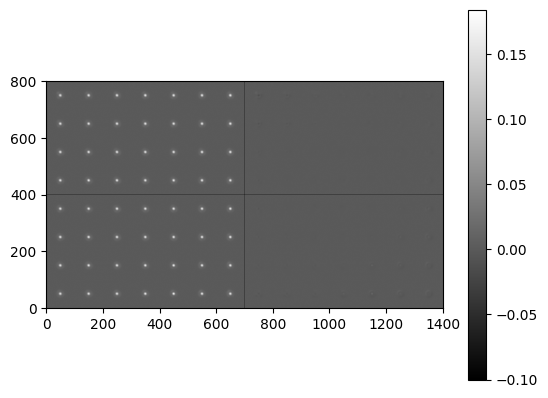

In [7]:
plt.imshow(data, origin="lower", cmap="gray")
plt.colorbar()
plt.show()

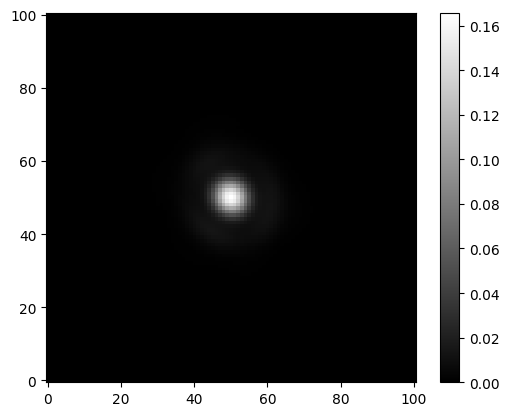

In [9]:
cx, cy = (350,650)
dx = dy = 50
plt.imshow(data[cy-dy:cy+dy+1, cx-dx:cx+dx+1], origin="lower", cmap="gray")
plt.colorbar()
plt.show()

In [10]:
data[cy-dy:cy+dy+1, cx-dx:cx+dx+1].shape

(101, 101)

In [11]:
oversample = 4
psf = sp.ndimage.zoom(data[cy-dy:cy+dy+1, cx-dx:cx+dx+1], 1/oversample)

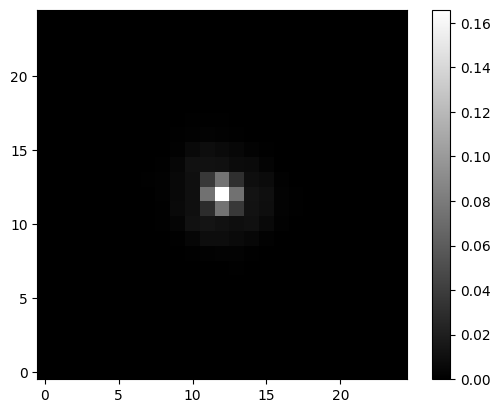

In [12]:
plt.imshow(psf, origin="lower", cmap="gray")
plt.colorbar()
plt.show()

In [ ]:
psf /= np.sum(psf)
np.save("data/psf", psf)